In [62]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [63]:
import os

# These are your exact paths based on your Drive structure
TRAIN_DIR = '/content/drive/MyDrive/AI coursework/Fruit Classification/Train'
TEST_DIR  = '/content/drive/MyDrive/AI coursework/Fruit Classification/Test'

# Verify the paths are correct
print('Train folder exists:', os.path.exists(TRAIN_DIR))
print('Test folder exists:', os.path.exists(TEST_DIR))

# Show class folders inside Train
print('\nClasses found:', os.listdir(TRAIN_DIR))

Train folder exists: True
Test folder exists: True

Classes found: ['Cherry', 'Peach', 'Mango', 'Banana', 'Grape']


In [64]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import os, time, warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout,
    BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.preprocessing import image as keras_image

print('TensorFlow:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [65]:
BASE_DIR  = '/content/drive/MyDrive/AI coursework/Fruit Classification'
TRAIN_DIR = os.path.join(BASE_DIR, 'Train')
TEST_DIR  = os.path.join(BASE_DIR, 'Test')

IMG_SIZE    = (100, 100)   # for CNN from scratch
TL_SIZE     = (224, 224)   # EfficientNetB0 expects 224x224
BATCH_SIZE  = 32
NUM_CLASSES = 5
CLASSES     = sorted(os.listdir(TRAIN_DIR))

print('Classes   :', CLASSES)
print('Num Classes:', NUM_CLASSES)

Classes   : ['Banana', 'Cherry', 'Grape', 'Mango', 'Peach']
Num Classes: 5


Dataset Analysis

Images per class:
  Banana    : 1422
  Cherry    : 1222
  Grape     : 1468
  Mango     : 908
  Peach     : 1222
  Total     : 6242


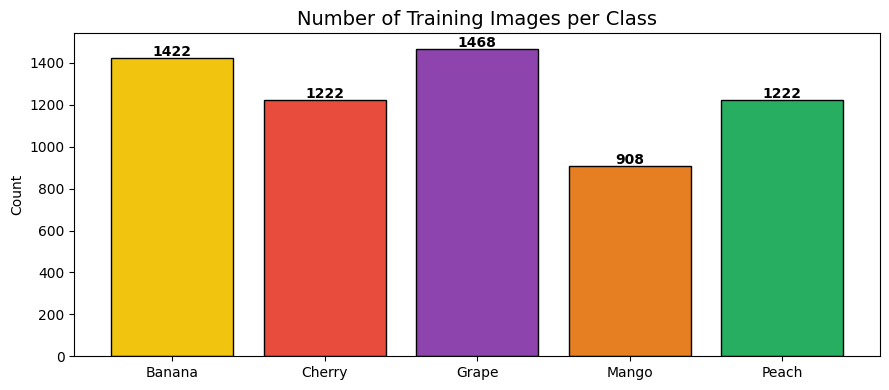

In [66]:
class_counts = {}
for cls in CLASSES:
    path  = os.path.join(TRAIN_DIR, cls)
    count = len([f for f in os.listdir(path) if f.endswith('.jpg')])
    class_counts[cls] = count

print('Images per class:')
for cls, count in class_counts.items():
    print(f'  {cls:10s}: {count}')
print(f'  {"Total":10s}: {sum(class_counts.values())}')

colors = ['#f1c40f', '#e74c3c', '#8e44ad', '#e67e22', '#27ae60']

plt.figure(figsize=(9, 4))
bars = plt.bar(class_counts.keys(), class_counts.values(), color=colors, edgecolor='black')
for bar, v in zip(bars, class_counts.values()):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 10, str(v), ha='center', fontweight='bold')
plt.title('Number of Training Images per Class', fontsize=14)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Sample Images per Class

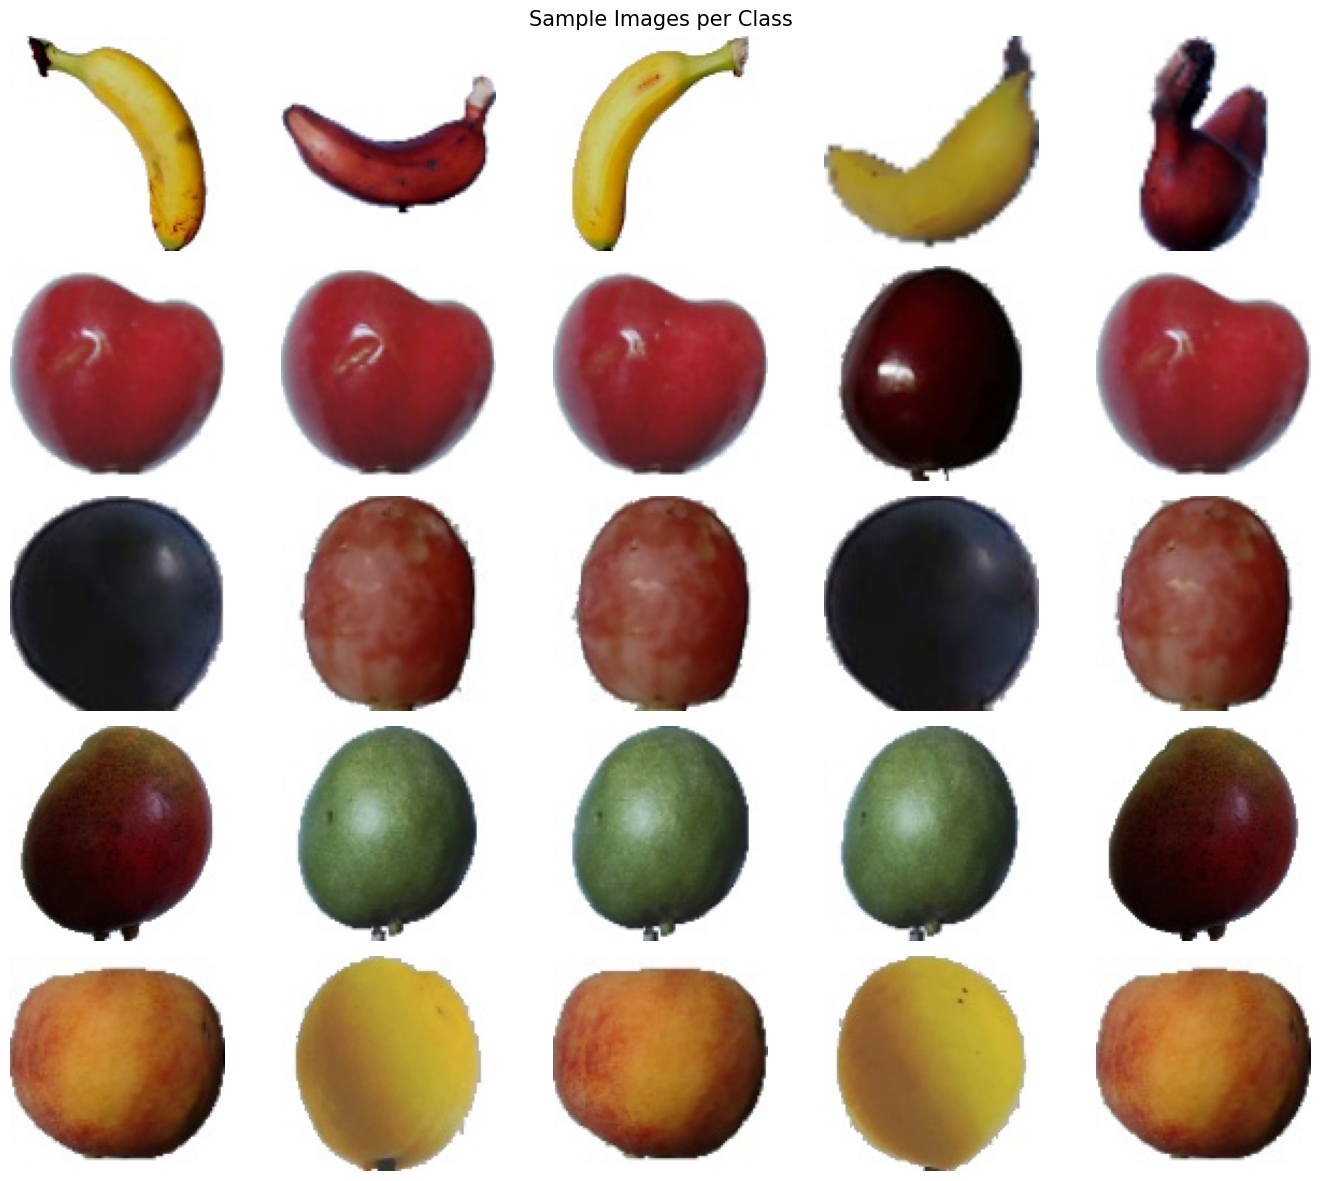

In [67]:
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(14, 12))

for row, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    imgs = [f for f in os.listdir(cls_path) if f.endswith('.jpg')][:5]
    for col, img_name in enumerate(imgs):
        img = mpimg.imread(os.path.join(cls_path, img_name))
        axes[row][col].imshow(img)
        axes[row][col].axis('off')
        if col == 0:
            axes[row][col].set_ylabel(cls, fontsize=12, fontweight='bold',
                                       rotation=0, labelpad=60, va='center')

plt.suptitle('Sample Images per Class', fontsize=15)
plt.tight_layout()
plt.show()

Data Generators

In [68]:
# Training with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    validation_split=0.2
)

# Validation/Test — only rescale
test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print('Class indices:', train_gen.class_indices)

Found 4996 images belonging to 5 classes.
Found 1246 images belonging to 5 classes.
Class indices: {'Banana': 0, 'Cherry': 1, 'Grape': 2, 'Mango': 3, 'Peach': 4}


In [69]:
from PIL import Image
import os

def clean_corrupt_images(directory):
    removed = 0
    for root, dirs, files in os.walk(directory):
        for fname in files:
            fpath = os.path.join(root, fname)
            try:
                with Image.open(fpath) as img:
                    img.verify()   # check if it's a valid image
            except Exception:
                print(f"Removing corrupt file: {fpath}")
                os.remove(fpath)
                removed += 1
    print(f"\nDone! Removed {removed} corrupt files.")

clean_corrupt_images(TRAIN_DIR)
clean_corrupt_images(TEST_DIR)


Done! Removed 0 corrupt files.

Done! Removed 0 corrupt files.


Visualize Augmented Images

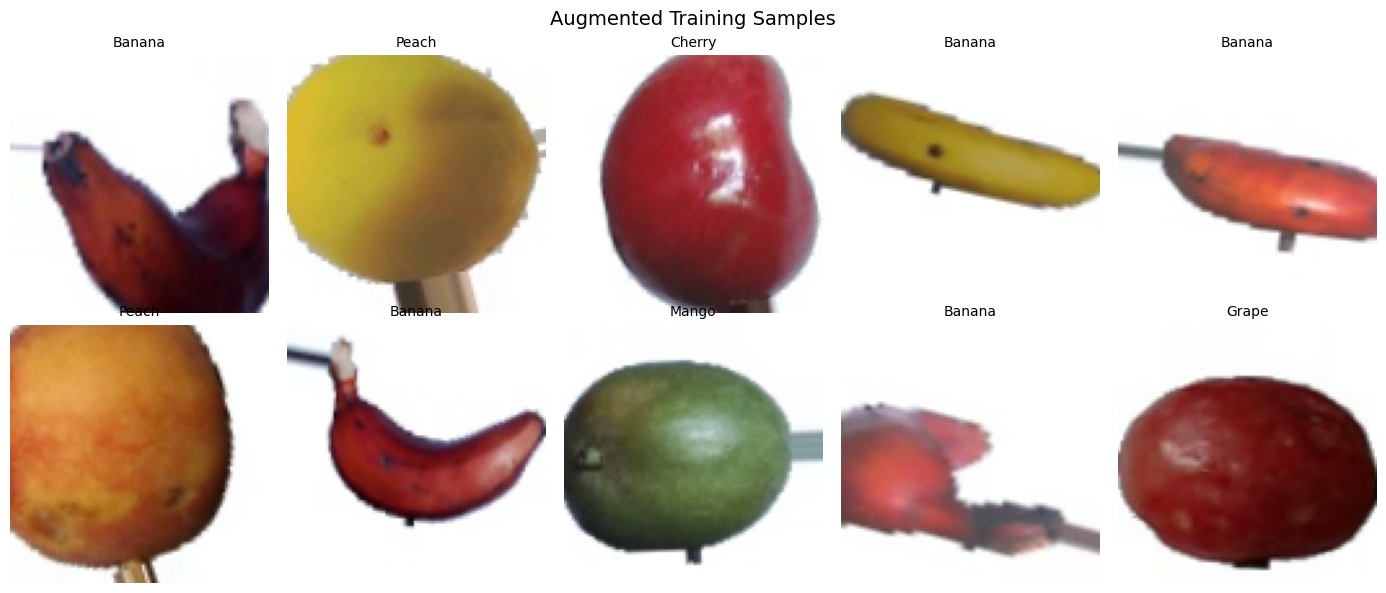

In [70]:
images, labels = next(train_gen)
class_names    = list(train_gen.class_indices.keys())

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
for i, ax in enumerate(axes.flatten()):
    ax.imshow(images[i])
    ax.set_title(class_names[np.argmax(labels[i])], fontsize=10)
    ax.axis('off')

plt.suptitle('Augmented Training Samples', fontsize=14)
plt.tight_layout()
plt.show()

In [71]:
def get_callbacks():
    return [
        EarlyStopping(monitor='val_loss', patience=5,
                      restore_best_weights=True, verbose=1),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=3, verbose=1)
    ]

Baseline CNN (Build)

In [72]:
def build_baseline():
    model = Sequential(name='Baseline_CNN')

    # Conv Block 1
    model.add(Conv2D(32, (3,3), activation='relu', input_shape=(100,100,3)))
    model.add(MaxPooling2D(2,2))

    # Conv Block 2
    model.add(Conv2D(64, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    # Conv Block 3
    model.add(Conv2D(128, (3,3), activation='relu'))
    model.add(MaxPooling2D(2,2))

    # Fully Connected Layers
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dense(128, activation='relu'))
    model.add(Dense(64,  activation='relu'))

    # Output
    model.add(Dense(NUM_CLASSES, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

baseline_model = build_baseline()
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_31 (Conv2D)              │ (None, 98, 98, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 49, 49, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_32 (Conv2D)              │ (None, 47, 47, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_33 (Conv2D)              │ (None, 21, 21, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 256)            │     3,277,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,411,781 (13.01 MB)

 Trainable params: 3,411,781 (13.01 MB)

 Non-trainable params: 0 (0.00 B)

Train Baseline

In [73]:
start = time.time()

history_base = baseline_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=get_callbacks(),
    verbose=1
)

baseline_time = time.time() - start
print(f'\nBaseline training time: {baseline_time:.1f} seconds')

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 48s 281ms/step - accuracy: 0.8725 - loss: 0.3297 - val_accuracy: 0.9831 - val_loss: 0.0642 - learning_rate: 0.0010
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 247ms/step - accuracy: 0.9794 - loss: 0.0722 - val_accuracy: 0.9751 - val_loss: 0.0919 - learning_rate: 0.0010
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 240ms/step - accuracy: 0.9902 - loss: 0.0288 - val_accuracy: 0.9663 - val_loss: 0.1383 - learning_rate: 0.0010
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 228ms/step - accuracy: 0.9934 - loss: 0.0275 - val_accuracy: 0.9936 - val_loss: 0.0242 - learning_rate: 0.0010
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 238ms/step - accuracy: 0.9944 - loss: 0.0181 - val_accuracy: 0.9807 - val_loss: 0.0553 - learning_rate: 0.0010
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 228ms/step - accuracy: 0.9896 - loss: 0.0337 - val_accuracy: 0.9791 - val_loss: 0.0555 - learning_rate: 0.0010
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 234ms/step - accuracy: 0.9

Plot Baseline Loss & Accuracy Curves

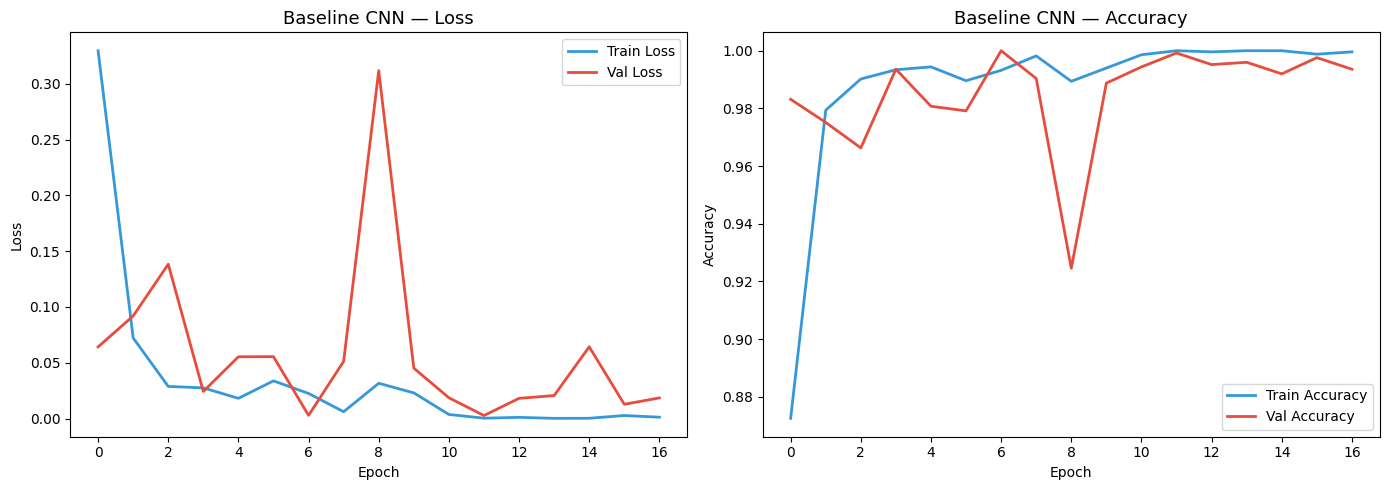

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(history_base.history['loss'],     label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(history_base.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_title('Baseline CNN — Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

# Accuracy
axes[1].plot(history_base.history['accuracy'],     label='Train Accuracy', color='#3498db', linewidth=2)
axes[1].plot(history_base.history['val_accuracy'], label='Val Accuracy',   color='#e74c3c', linewidth=2)
axes[1].set_title('Baseline CNN — Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Evaluate Baseline Model

In [75]:
# Reset generator before evaluation
val_gen.reset()
loss_b, acc_b = baseline_model.evaluate(val_gen, verbose=1)
print(f'\nBaseline Accuracy : {acc_b:.4f}')
print(f'Baseline Loss     : {loss_b:.4f}')

39/39 ━━━━━━━━━━━━━━━━━━━━ 7s 183ms/step - accuracy: 0.9984 - loss: 0.0093

Baseline Accuracy : 0.9984
Baseline Loss     : 0.0093


Classification Report & Confusion Matrix (Baseline)

39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 199ms/step
Classification Report:
              precision    recall  f1-score   support

      Banana       0.24      0.23      0.23       284
      Cherry       0.17      0.17      0.17       244
       Grape       0.26      0.26      0.26       293
       Mango       0.17      0.17      0.17       181
       Peach       0.23      0.23      0.23       244

    accuracy                           0.22      1246
   macro avg       0.21      0.21      0.21      1246
weighted avg       0.22      0.22      0.22      1246



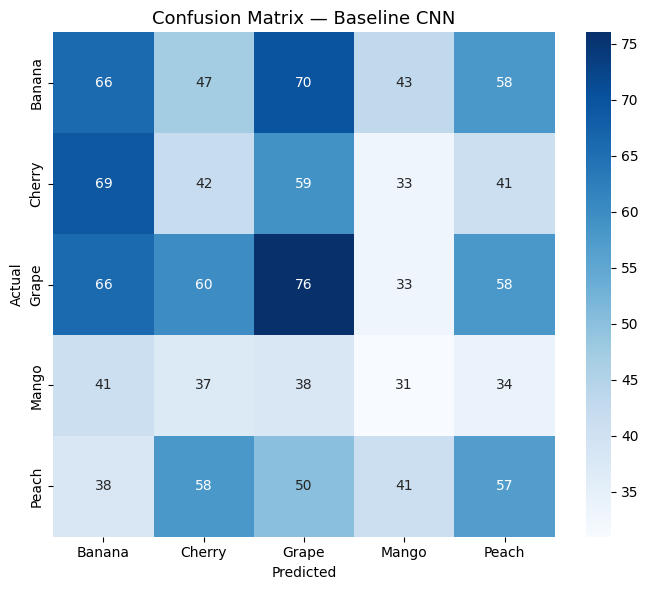

In [76]:
val_gen.reset()
y_pred_b = np.argmax(baseline_model.predict(val_gen, verbose=1), axis=1)
y_true   = val_gen.classes

print('Classification Report:')
print(classification_report(y_true, y_pred_b, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred_b)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Baseline CNN', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Sample Inference on Baseline

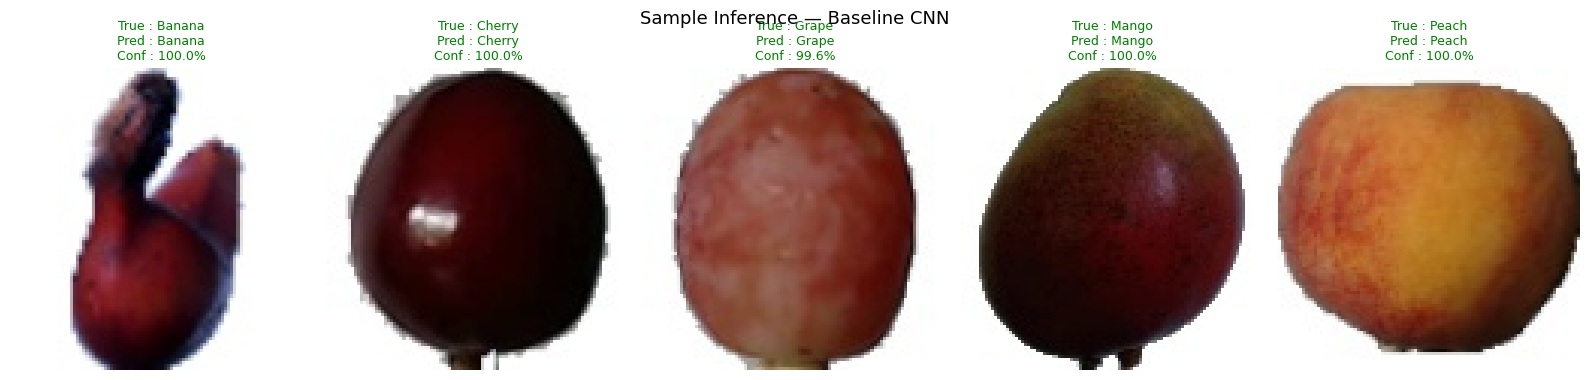

In [77]:
# Pick one real image from each class and predict
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for i, cls in enumerate(CLASSES):
    cls_path  = os.path.join(TRAIN_DIR, cls)
    img_file  = os.listdir(cls_path)[5]           # pick 6th image
    img_path  = os.path.join(cls_path, img_file)

    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    arr = keras_image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs = baseline_model.predict(arr, verbose=0)[0]
    pred  = CLASSES[np.argmax(probs)]
    conf  = probs.max()

    color = 'green' if pred == cls else 'red'
    axes[i].imshow(img)
    axes[i].set_title(f'True : {cls}\nPred : {pred}\nConf : {conf:.1%}',
                      color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Inference — Baseline CNN', fontsize=13)
plt.tight_layout()
plt.show()

Build Deeper CNN

In [78]:
# Deeper model — double the layers vs baseline
# Added BatchNormalization and Dropout for regularization

def build_deeper():
    model = Sequential(name='Deeper_CNN')

    # Block 1
    model.add(Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(100,100,3)))
    model.add(BatchNormalization())
    model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.25))

    # Block 2
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.25))

    # Block 3
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.25))

    # Block 4 — extra depth
    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(BatchNormalization())
    model.add(Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.3))

    # FCN
    model.add(Flatten())
    model.add(Dense(512, activation='relu'))
    model.add(BatchNormalization())
    model.add(Dropout(0.5))
    model.add(Dense(256, activation='relu'))
    model.add(Dense(NUM_CLASSES, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

deeper_model = build_deeper()
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_34 (Conv2D)              │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 100, 100, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_35 (Conv2D)              │ (None, 100, 100, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 50, 50, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 50, 50, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 25, 25, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_39 (Conv2D)              │ (None, 25, 25, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_25 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_40 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_41 (Conv2D)              │ (None, 12, 12, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_26 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 512)            │     4,719,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 512)            │         2,04

 Total params: 6,027,941 (22.99 MB)

 Trainable params: 6,025,957 (22.99 MB)

 Non-trainable params: 1,984 (7.75 KB)

Train Deeper Model

In [79]:
start = time.time()

history_deep = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=30,
    callbacks=get_callbacks(),
    verbose=1
)

deeper_time = time.time() - start
print(f'Deeper model training time: {deeper_time:.1f} seconds')

Epoch 1/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 316ms/step - accuracy: 0.9107 - loss: 0.2602 - val_accuracy: 0.1453 - val_loss: 10.8945 - learning_rate: 0.0010
Epoch 2/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 39s 248ms/step - accuracy: 0.9307 - loss: 0.2393 - val_accuracy: 0.6132 - val_loss: 2.8415 - learning_rate: 0.0010
Epoch 3/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 238ms/step - accuracy: 0.9562 - loss: 0.1375 - val_accuracy: 0.7889 - val_loss: 1.0978 - learning_rate: 0.0010
Epoch 4/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 233ms/step - accuracy: 0.9726 - loss: 0.0890 - val_accuracy: 0.8933 - val_loss: 0.3743 - learning_rate: 0.0010
Epoch 5/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 241ms/step - accuracy: 0.9900 - loss: 0.0303 - val_accuracy: 0.9671 - val_loss: 0.1540 - learning_rate: 0.0010
Epoch 6/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 38s 241ms/step - accuracy: 0.9844 - loss: 0.0541 - val_accuracy: 0.9904 - val_loss: 0.0304 - learning_rate: 0.0010
Epoch 7/30
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 234ms/step - accuracy: 0.

Plot Deeper Model Curves

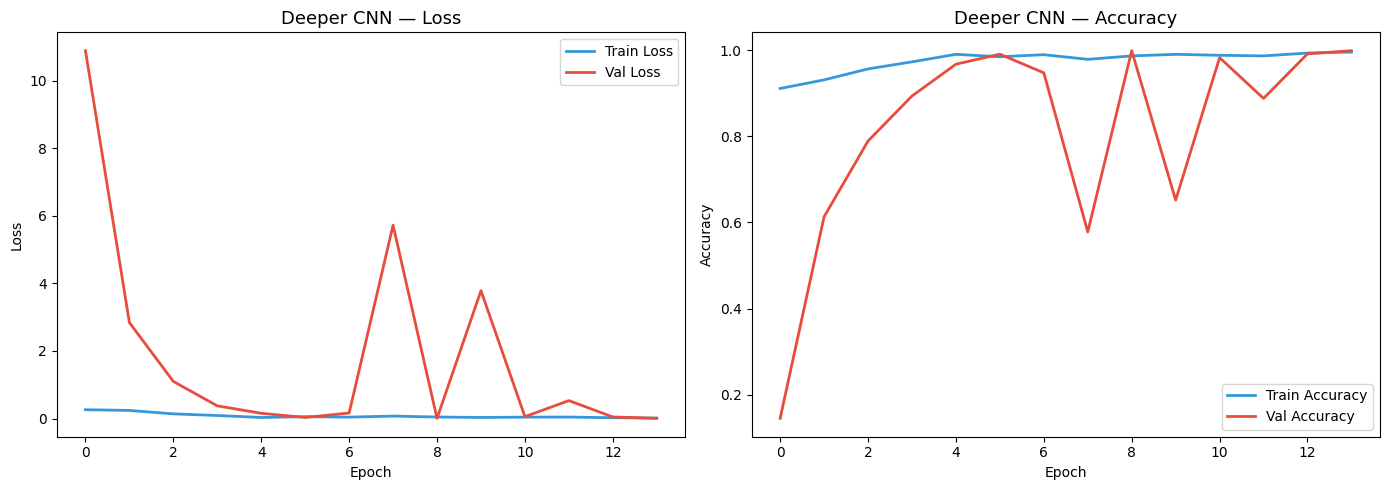

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deep.history['loss'],     label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(history_deep.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_title('Deeper CNN — Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_deep.history['accuracy'],     label='Train Accuracy', color='#3498db', linewidth=2)
axes[1].plot(history_deep.history['val_accuracy'], label='Val Accuracy',   color='#e74c3c', linewidth=2)
axes[1].set_title('Deeper CNN — Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Evaluate Deeper Model

In [81]:
val_gen.reset()
loss_d, acc_d = deeper_model.evaluate(val_gen, verbose=1)
print(f'\nDeeper Accuracy : {acc_d:.4f}')
print(f'Deeper Loss     : {loss_d:.4f}')

39/39 ━━━━━━━━━━━━━━━━━━━━ 8s 200ms/step - accuracy: 0.9976 - loss: 0.0065

Deeper Accuracy : 0.9976
Deeper Loss     : 0.0065


Classification Report & Confusion Matrix (Deeper)

39/39 ━━━━━━━━━━━━━━━━━━━━ 9s 197ms/step
Classification Report:
              precision    recall  f1-score   support

      Banana       0.25      0.25      0.25       284
      Cherry       0.20      0.20      0.20       244
       Grape       0.24      0.24      0.24       293
       Mango       0.11      0.11      0.11       181
       Peach       0.19      0.19      0.19       244

    accuracy                           0.21      1246
   macro avg       0.20      0.20      0.20      1246
weighted avg       0.21      0.21      0.21      1246



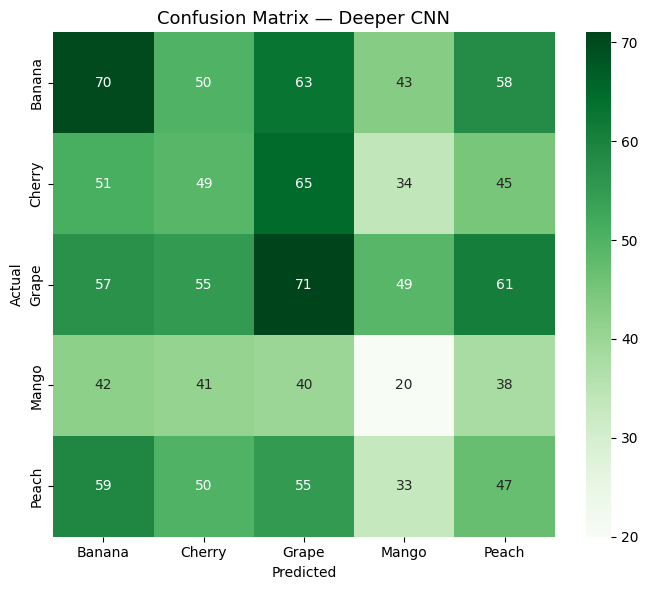

In [82]:
val_gen.reset()
y_pred_d = np.argmax(deeper_model.predict(val_gen, verbose=1), axis=1)

print('Classification Report:')
print(classification_report(y_true, y_pred_d, target_names=CLASSES))

cm = confusion_matrix(y_true, y_pred_d)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — Deeper CNN', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Sample Inference on Deeper Model

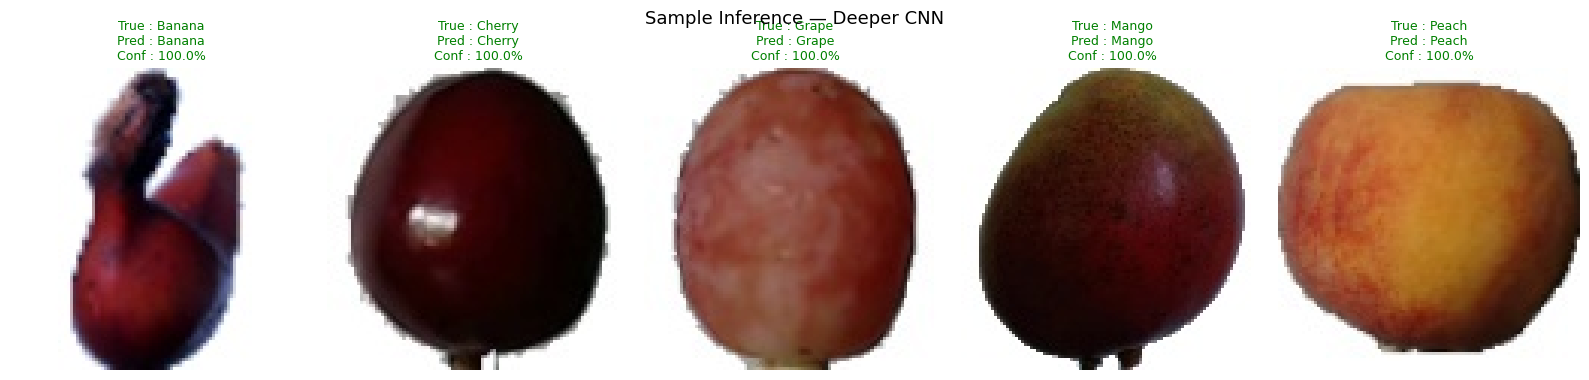

In [83]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for i, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[5]
    img_path = os.path.join(cls_path, img_file)

    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    arr = keras_image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)

    probs = deeper_model.predict(arr, verbose=0)[0]
    pred  = CLASSES[np.argmax(probs)]
    conf  = probs.max()

    color = 'green' if pred == cls else 'red'
    axes[i].imshow(img)
    axes[i].set_title(f'True : {cls}\nPred : {pred}\nConf : {conf:.1%}',
                      color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Inference — Deeper CNN', fontsize=13)
plt.tight_layout()
plt.show()

 Baseline vs Deeper: Accuracy & Loss Comparison

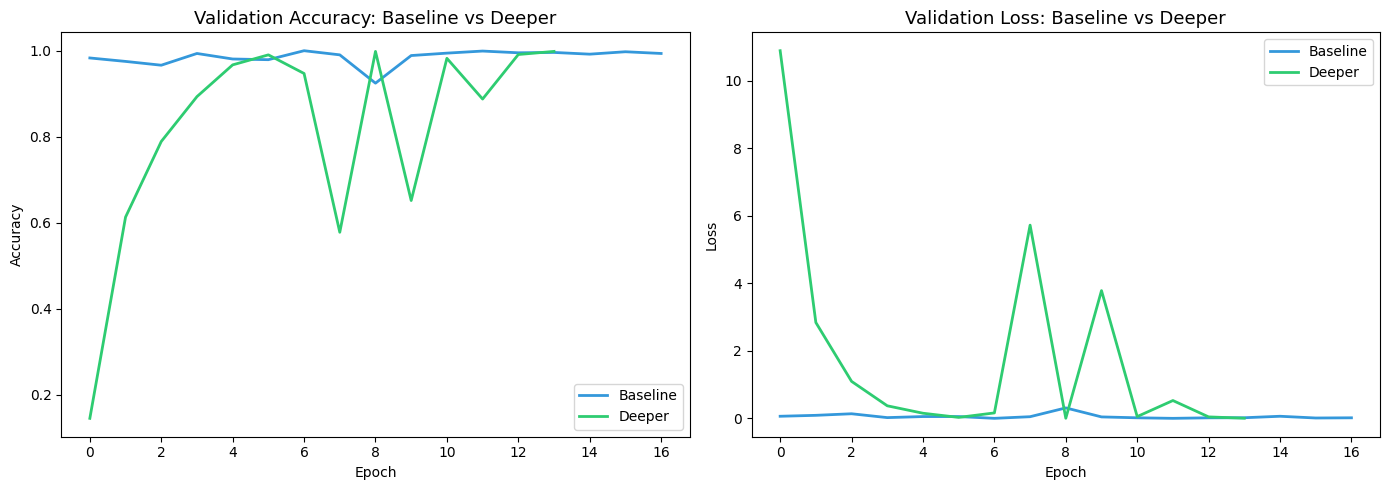

Baseline Accuracy : 0.9984 | Time: 647.1s
Deeper   Accuracy : 0.9976 | Time: 563.4s


In [84]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Val accuracy both models
axes[0].plot(history_base.history['val_accuracy'], label='Baseline', color='#3498db', linewidth=2)
axes[0].plot(history_deep.history['val_accuracy'], label='Deeper',   color='#2ecc71', linewidth=2)
axes[0].set_title('Validation Accuracy: Baseline vs Deeper', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

# Val loss both models
axes[1].plot(history_base.history['val_loss'], label='Baseline', color='#3498db', linewidth=2)
axes[1].plot(history_deep.history['val_loss'], label='Deeper',   color='#2ecc71', linewidth=2)
axes[1].set_title('Validation Loss: Baseline vs Deeper', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Baseline Accuracy : {acc_b:.4f} | Time: {baseline_time:.1f}s')
print(f'Deeper   Accuracy : {acc_d:.4f} | Time: {deeper_time:.1f}s')

Computational Efficiency Comparison

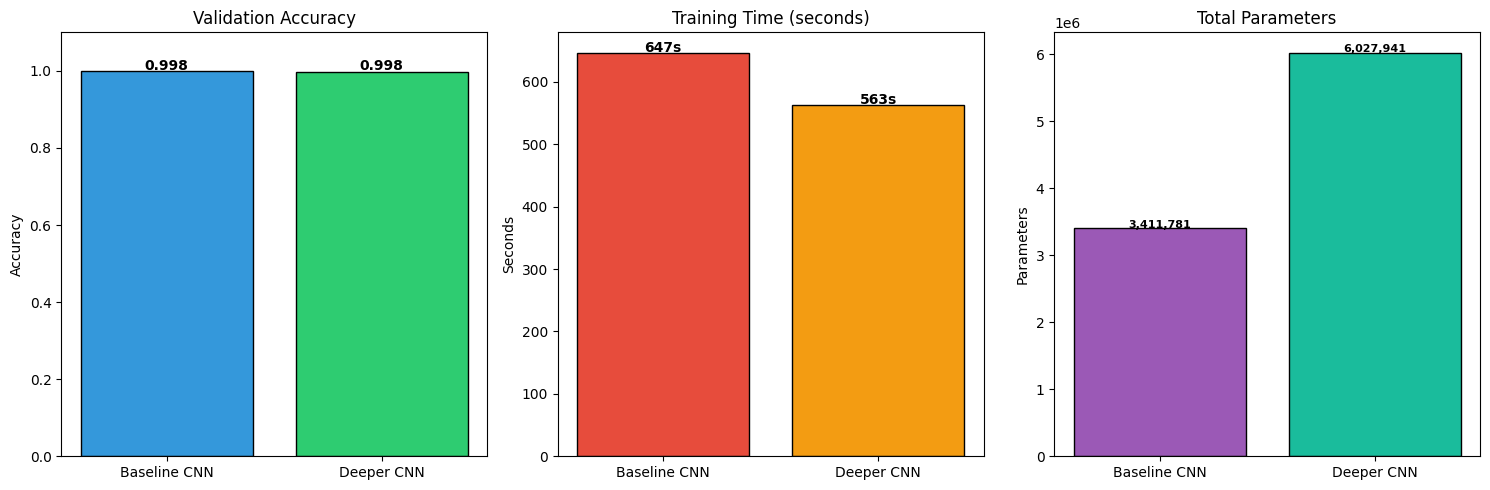

In [85]:
names  = ['Baseline CNN', 'Deeper CNN']
accs   = [acc_b, acc_d]
times  = [baseline_time, deeper_time]
params = [baseline_model.count_params(), deeper_model.count_params()]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Accuracy
axes[0].bar(names, accs, color=['#3498db','#2ecc71'], edgecolor='black')
for i, v in enumerate(accs):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].set_title('Validation Accuracy', fontsize=12)
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 1.1)

# Training time
axes[1].bar(names, times, color=['#e74c3c','#f39c12'], edgecolor='black')
for i, v in enumerate(times):
    axes[1].text(i, v + 1, f'{v:.0f}s', ha='center', fontweight='bold')
axes[1].set_title('Training Time (seconds)', fontsize=12)
axes[1].set_ylabel('Seconds')

# Parameters
axes[2].bar(names, params, color=['#9b59b6','#1abc9c'], edgecolor='black')
for i, v in enumerate(params):
    axes[2].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold', fontsize=8)
axes[2].set_title('Total Parameters', fontsize=12)
axes[2].set_ylabel('Parameters')

plt.tight_layout()
plt.show()

Optimizer Analysis: SGD vs Adam

In [86]:
# Train deeper model with SGD
model_sgd = build_deeper()
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('Training with SGD...')
history_sgd = model_sgd.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=get_callbacks(),
    verbose=1
)

val_gen.reset()
_, acc_sgd = model_sgd.evaluate(val_gen, verbose=0)
print(f'\nSGD Accuracy: {acc_sgd:.4f}')

Training with SGD...
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 56s 293ms/step - accuracy: 0.8343 - loss: 0.4492 - val_accuracy: 0.5522 - val_loss: 1.9950 - learning_rate: 0.0100
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 255ms/step - accuracy: 0.9486 - loss: 0.1585 - val_accuracy: 0.3676 - val_loss: 4.1559 - learning_rate: 0.0100
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 234ms/step - accuracy: 0.9574 - loss: 0.1261 - val_accuracy: 0.9286 - val_loss: 0.1724 - learning_rate: 0.0100
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 232ms/step - accuracy: 0.9908 - loss: 0.0333 - val_accuracy: 0.8780 - val_loss: 0.5483 - learning_rate: 0.0100
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 236ms/step - accuracy: 0.9868 - loss: 0.0400 - val_accuracy: 0.9904 - val_loss: 0.0247 - learning_rate: 0.0100
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 230ms/step - accuracy: 0.9872 - loss: 0.0419 - val_accuracy: 0.7520 - val_loss: 0.9777 - learning_rate: 0.0100
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 41s 233ms

Plot SGD vs Adam

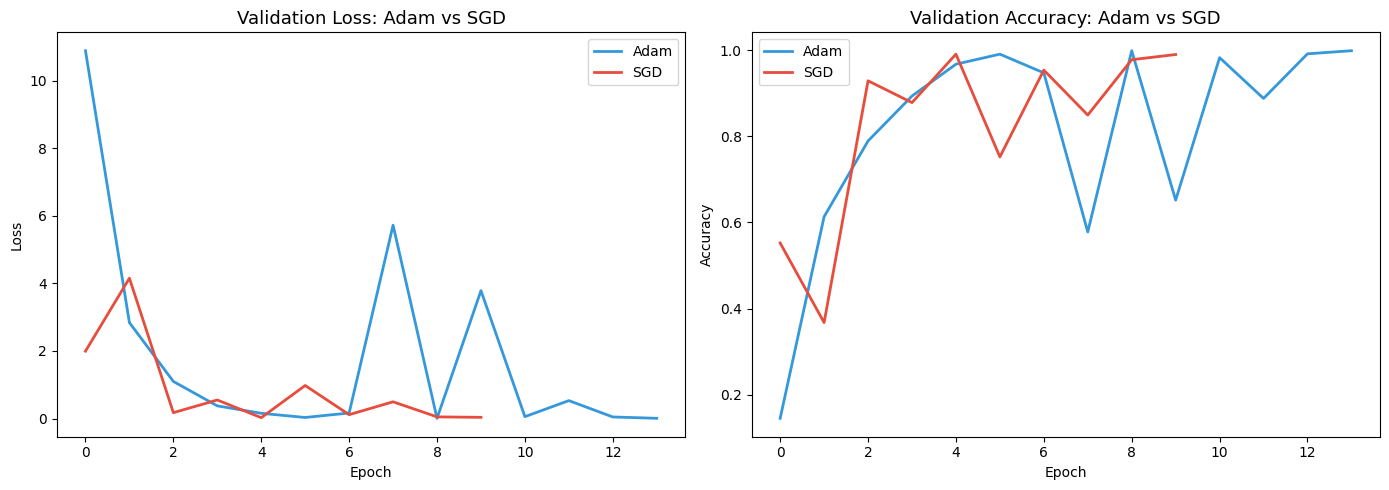

Adam Accuracy : 0.9976
SGD  Accuracy : 0.9952


In [87]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_deep.history['val_loss'], label='Adam', color='#3498db', linewidth=2)
axes[0].plot(history_sgd.history['val_loss'],  label='SGD',  color='#e74c3c', linewidth=2)
axes[0].set_title('Validation Loss: Adam vs SGD', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_deep.history['val_accuracy'], label='Adam', color='#3498db', linewidth=2)
axes[1].plot(history_sgd.history['val_accuracy'],  label='SGD',  color='#e74c3c', linewidth=2)
axes[1].set_title('Validation Accuracy: Adam vs SGD', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Adam Accuracy : {acc_d:.4f}')
print(f'SGD  Accuracy : {acc_sgd:.4f}')

Ablation Study: Remove BatchNormalization

In [88]:
def build_no_batchnorm():
    model = Sequential(name='No_BatchNorm')

    model.add(Conv2D(32,  (3,3), activation='relu', padding='same', input_shape=(100,100,3)))
    model.add(Conv2D(32,  (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.25))

    model.add(Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(Conv2D(64,  (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.25))

    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(MaxPooling2D(2,2))
    model.add(Dropout(0.3))

    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(NUM_CLASSES, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model_no_bn = build_no_batchnorm()

print('Training without BatchNormalization...')
history_no_bn = model_no_bn.fit(
    train_gen,
    validation_data=val_gen,
    epochs=20,
    callbacks=get_callbacks(),
    verbose=1
)

val_gen.reset()
_, acc_no_bn = model_no_bn.evaluate(val_gen, verbose=0)
print(f'\nWithout BatchNorm Accuracy: {acc_no_bn:.4f}')
print(f'With    BatchNorm Accuracy: {acc_d:.4f}')

Training without BatchNormalization...
Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 50s 271ms/step - accuracy: 0.6257 - loss: 0.8472 - val_accuracy: 0.8066 - val_loss: 0.4202 - learning_rate: 0.0010
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 230ms/step - accuracy: 0.9193 - loss: 0.2309 - val_accuracy: 0.9478 - val_loss: 0.1525 - learning_rate: 0.0010
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 235ms/step - accuracy: 0.9734 - loss: 0.0823 - val_accuracy: 0.9462 - val_loss: 0.1254 - learning_rate: 0.0010
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 36s 227ms/step - accuracy: 0.9598 - loss: 0.1298 - val_accuracy: 0.9775 - val_loss: 0.0635 - learning_rate: 0.0010
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 40s 252ms/step - accuracy: 0.9842 - loss: 0.0477 - val_accuracy: 0.9864 - val_loss: 0.0634 - learning_rate: 0.0010
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 37s 234ms/step - accuracy: 0.9922 - loss: 0.0214 - val_accuracy: 0.9230 - val_loss: 0.5689 - learning_rate: 0.0010
Epoch 7/20
157/157 ━━━━━━━━━━━━

Plot Ablation Study

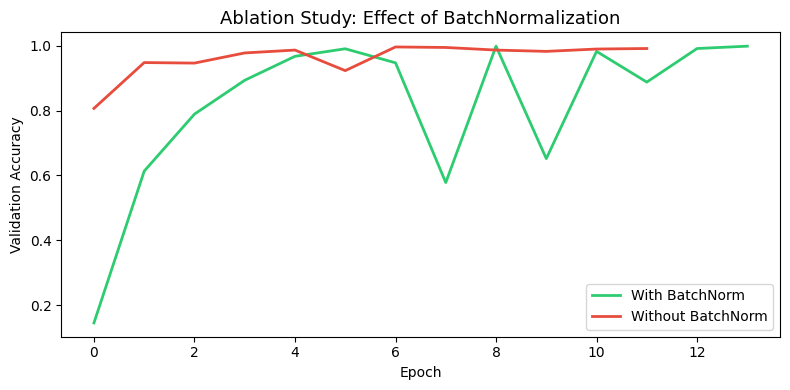

In [89]:
plt.figure(figsize=(8, 4))
plt.plot(history_deep.history['val_accuracy'],
         label='With BatchNorm',    color='#2ecc71', linewidth=2)
plt.plot(history_no_bn.history['val_accuracy'],
         label='Without BatchNorm', color='#e74c3c', linewidth=2)
plt.title('Ablation Study: Effect of BatchNormalization', fontsize=13)
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.tight_layout()
plt.show()

EfficientNetB0 Generators (224x224)

In [103]:
from tensorflow.keras.applications.efficientnet import preprocess_input

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    horizontal_flip=True,
    zoom_range=0.15,
    validation_split=0.2
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=TL_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42
)

tl_val_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=TL_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42
)

print('Train batches:', len(tl_train_gen))
print('Val   batches:', len(tl_val_gen))

Found 4996 images belonging to 5 classes.
Found 1246 images belonging to 5 classes.
Train batches: 157
Val   batches: 39


Build EfficientNetB0

In [104]:
# Load EfficientNetB0 pre-trained on ImageNet
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all base layers first
base_model.trainable = False

# Add our own classification head for 5 fruit classes
inputs  = Input(shape=(224, 224, 3))
x       = base_model(inputs, training=False)
x       = GlobalAveragePooling2D()(x)
x       = Dense(256, activation='relu')(x)
x       = Dropout(0.4)(x)
x       = Dense(128, activation='relu')(x)
x       = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

eff_model = Model(inputs, outputs, name='EfficientNetB0')

eff_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Total parameters     : {eff_model.count_params():,}')
print(f'Base layers frozen   : {len([l for l in base_model.layers if not l.trainable])}')
eff_model.summary()

Total parameters     : 4,411,048
Base layers frozen   : 238


Model: "EfficientNetB0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_15 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_32 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,411,048 (16.83 MB)

 Trainable params: 361,477 (1.38 MB)

 Non-trainable params: 4,049,571 (15.45 MB)

Phase 1: Feature Extraction (Base Frozen)

In [105]:
print('=== PHASE 1: Training with frozen EfficientNetB0 base ===')

start = time.time()

history_phase1 = eff_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=15,
    callbacks=get_callbacks(),
    verbose=1
)

phase1_time = time.time() - start
print(f'\nPhase 1 training time: {phase1_time:.1f} seconds')

=== PHASE 1: Training with frozen EfficientNetB0 base ===
Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 138s 743ms/step - accuracy: 0.9632 - loss: 0.1156 - val_accuracy: 1.0000 - val_loss: 0.0044 - learning_rate: 0.0010
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 91s 581ms/step - accuracy: 0.9956 - loss: 0.0117 - val_accuracy: 1.0000 - val_loss: 2.6532e-04 - learning_rate: 0.0010
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 95s 604ms/step - accuracy: 0.9982 - loss: 0.0070 - val_accuracy: 0.9583 - val_loss: 0.0876 - learning_rate: 0.0010
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 92s 585ms/step - accuracy: 0.9926 - loss: 0.0187 - val_accuracy: 0.9920 - val_loss: 0.0181 - learning_rate: 0.0010
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 94s 594ms/step - accuracy: 0.9992 - loss: 0.0027 - val_accuracy: 1.0000 - val_loss: 6.4274e-05 - learning_rate: 0.0010
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 94s 599ms/step - accuracy: 0.9974 - loss: 0.0108 - val_accuracy: 1.0000 - val_loss: 4.0074e-04 - learning_rate: 0.0010

Plot Phase 1 Curves

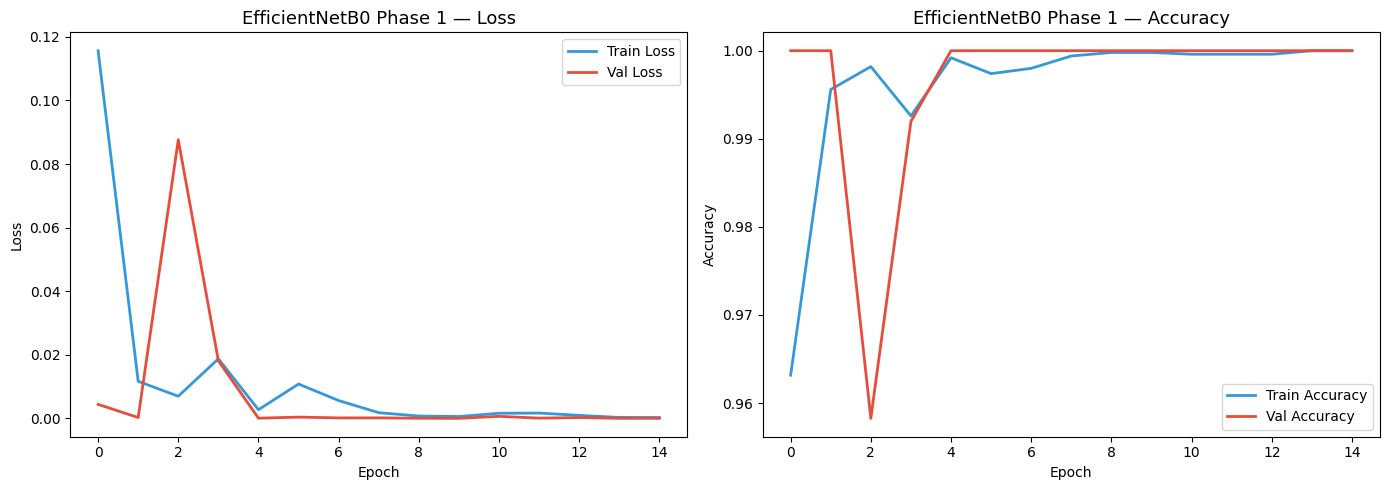

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_phase1.history['loss'],     label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(history_phase1.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_title('EfficientNetB0 Phase 1 — Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_phase1.history['accuracy'],     label='Train Accuracy', color='#3498db', linewidth=2)
axes[1].plot(history_phase1.history['val_accuracy'], label='Val Accuracy',   color='#e74c3c', linewidth=2)
axes[1].set_title('EfficientNetB0 Phase 1 — Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Phase 2: Fine-Tuning (Unfreeze Last 20 Layers)

In [107]:
print('=== PHASE 2: Fine-tuning last 20 layers of EfficientNetB0 ===')

# Unfreeze last 20 layers
base_model.trainable = True
for layer in base_model.layers[:-20]:
    layer.trainable = False

print(f'Trainable layers now: {len([l for l in base_model.layers if l.trainable])}')

# Lower learning rate to avoid destroying pre-trained weights
eff_model.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_phase2 = eff_model.fit(
    tl_train_gen,
    validation_data=tl_val_gen,
    epochs=10,
    callbacks=get_callbacks(),
    verbose=1
)

print('Fine-tuning complete!')

=== PHASE 2: Fine-tuning last 20 layers of EfficientNetB0 ===
Trainable layers now: 20
Epoch 1/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 150s 773ms/step - accuracy: 0.9888 - loss: 0.0368 - val_accuracy: 0.9976 - val_loss: 0.0070 - learning_rate: 1.0000e-05
Epoch 2/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 93s 589ms/step - accuracy: 0.9934 - loss: 0.0216 - val_accuracy: 1.0000 - val_loss: 0.0025 - learning_rate: 1.0000e-05
Epoch 3/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 95s 603ms/step - accuracy: 0.9972 - loss: 0.0107 - val_accuracy: 0.9992 - val_loss: 0.0027 - learning_rate: 1.0000e-05
Epoch 4/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 93s 590ms/step - accuracy: 0.9976 - loss: 0.0093 - val_accuracy: 0.9984 - val_loss: 0.0057 - learning_rate: 1.0000e-05
Epoch 5/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 93s 590ms/step - accuracy: 0.9970 - loss: 0.0087 - val_accuracy: 1.0000 - val_loss: 9.5824e-04 - learning_rate: 1.0000e-05
Epoch 6/10
157/157 ━━━━━━━━━━━━━━━━━━━━ 92s 589ms/step - accuracy: 0.9962 - loss: 0.0096 - val_accuracy: 1.0000 -

Plot Phase 2 Curves

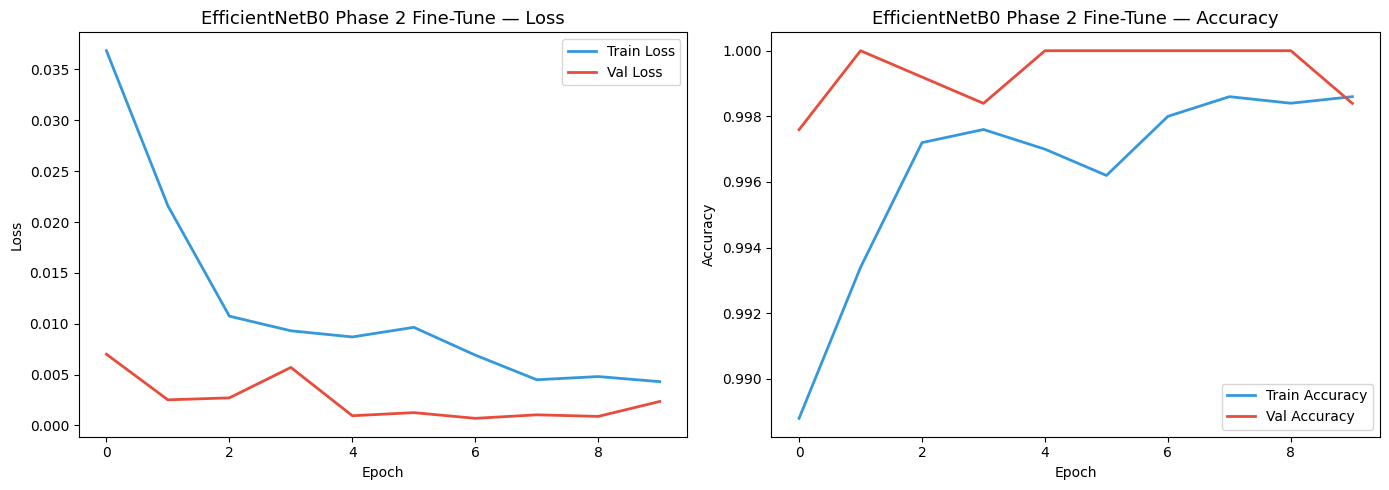

In [108]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_phase2.history['loss'],     label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(history_phase2.history['val_loss'], label='Val Loss',   color='#e74c3c', linewidth=2)
axes[0].set_title('EfficientNetB0 Phase 2 Fine-Tune — Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_phase2.history['accuracy'],     label='Train Accuracy', color='#3498db', linewidth=2)
axes[1].plot(history_phase2.history['val_accuracy'], label='Val Accuracy',   color='#e74c3c', linewidth=2)
axes[1].set_title('EfficientNetB0 Phase 2 Fine-Tune — Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Evaluate EfficientNetB0

In [109]:
tl_val_gen.reset()
loss_eff, acc_eff = eff_model.evaluate(tl_val_gen, verbose=1)
print(f'\nEfficientNetB0 Accuracy : {acc_eff:.4f}')
print(f'EfficientNetB0 Loss     : {loss_eff:.4f}')

39/39 ━━━━━━━━━━━━━━━━━━━━ 19s 474ms/step - accuracy: 0.9992 - loss: 0.0023

EfficientNetB0 Accuracy : 0.9992
EfficientNetB0 Loss     : 0.0023


Classification Report & Confusion Matrix (EfficientNetB0)


39/39 ━━━━━━━━━━━━━━━━━━━━ 38s 790ms/step
Classification Report:
              precision    recall  f1-score   support

      Banana       0.25      0.25      0.25       284
      Cherry       0.20      0.20      0.20       244
       Grape       0.23      0.23      0.23       293
       Mango       0.15      0.15      0.15       181
       Peach       0.19      0.19      0.19       244

    accuracy                           0.21      1246
   macro avg       0.20      0.20      0.20      1246
weighted avg       0.21      0.21      0.21      1246



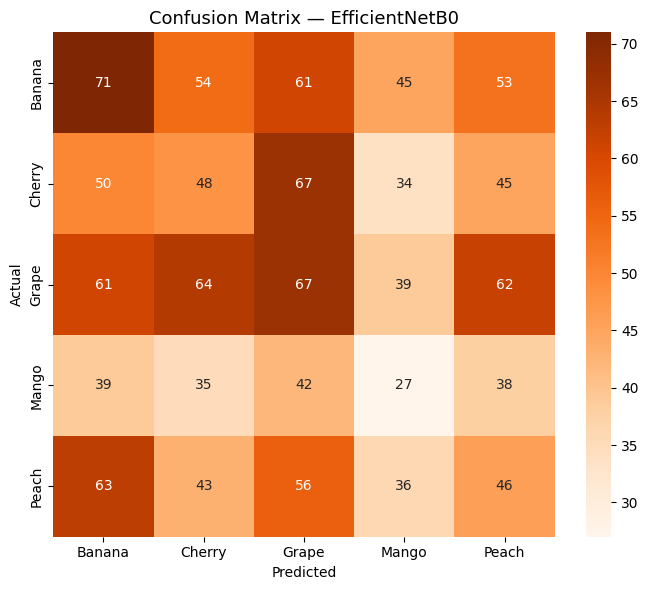

In [110]:
tl_val_gen.reset()
y_pred_eff = np.argmax(eff_model.predict(tl_val_gen, verbose=1), axis=1)
y_true_tl  = tl_val_gen.classes

print('Classification Report:')
print(classification_report(y_true_tl, y_pred_eff, target_names=CLASSES))

cm = confusion_matrix(y_true_tl, y_pred_eff)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix — EfficientNetB0', fontsize=13)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Sample Inference EfficientNetB0

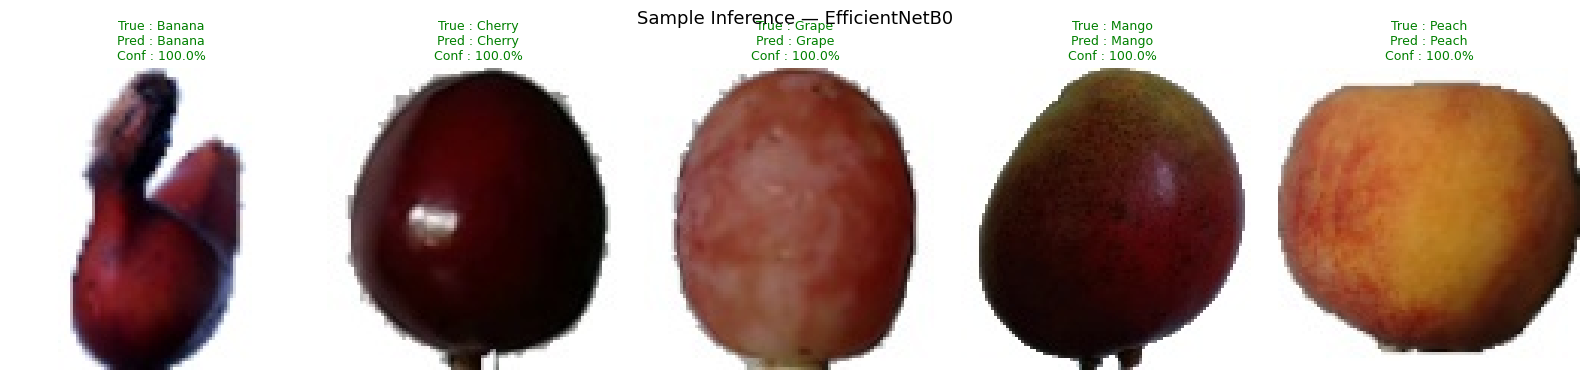

In [111]:
from tensorflow.keras.applications.efficientnet import preprocess_input

fig, axes = plt.subplots(1, 5, figsize=(16, 4))

for i, cls in enumerate(CLASSES):
    cls_path = os.path.join(TRAIN_DIR, cls)
    img_file = os.listdir(cls_path)[5]
    img_path = os.path.join(cls_path, img_file)

    img = keras_image.load_img(img_path, target_size=TL_SIZE)
    arr = preprocess_input(keras_image.img_to_array(img))
    arr = np.expand_dims(arr, axis=0)

    probs = eff_model.predict(arr, verbose=0)[0]
    pred  = CLASSES[np.argmax(probs)]
    conf  = probs.max()

    color = 'green' if pred == cls else 'red'
    axes[i].imshow(keras_image.load_img(img_path))
    axes[i].set_title(f'True : {cls}\nPred : {pred}\nConf : {conf:.1%}',
                      color=color, fontsize=9)
    axes[i].axis('off')

plt.suptitle('Sample Inference — EfficientNetB0', fontsize=13)
plt.tight_layout()
plt.show()

Phase 1 vs Phase 2 Comparison

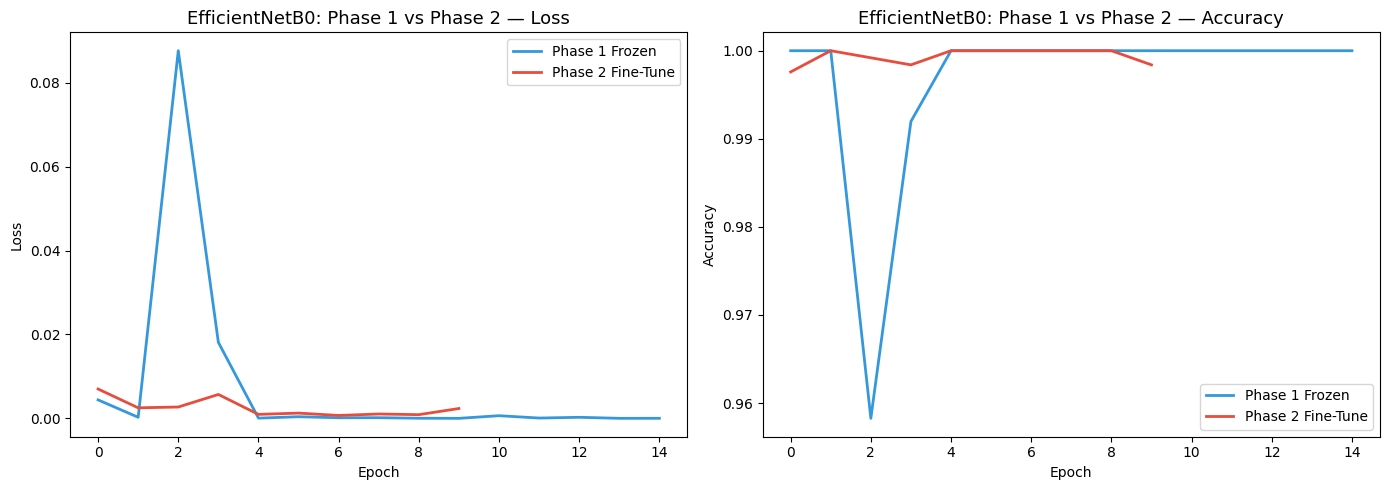

In [112]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history_phase1.history['val_loss'],
             label='Phase 1 Frozen',    color='#3498db', linewidth=2)
axes[0].plot(history_phase2.history['val_loss'],
             label='Phase 2 Fine-Tune', color='#e74c3c', linewidth=2)
axes[0].set_title('EfficientNetB0: Phase 1 vs Phase 2 — Loss', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(history_phase1.history['val_accuracy'],
             label='Phase 1 Frozen',    color='#3498db', linewidth=2)
axes[1].plot(history_phase2.history['val_accuracy'],
             label='Phase 2 Fine-Tune', color='#e74c3c', linewidth=2)
axes[1].set_title('EfficientNetB0: Phase 1 vs Phase 2 — Accuracy', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()

plt.tight_layout()
plt.show()

Final Comparison All Models

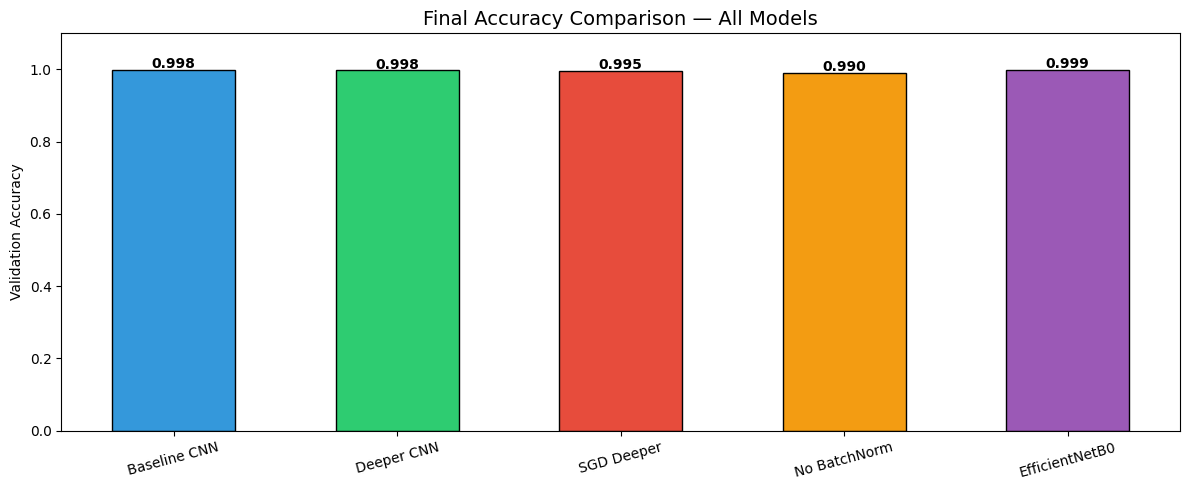


Final Summary:
  Baseline CNN        : 0.9984
  Deeper CNN          : 0.9976
  SGD Deeper          : 0.9952
  No BatchNorm        : 0.9904
  EfficientNetB0      : 0.9992


In [113]:
model_names = ['Baseline CNN', 'Deeper CNN', 'SGD Deeper', 'No BatchNorm', 'EfficientNetB0']
accuracies  = [acc_b, acc_d, acc_sgd, acc_no_bn, acc_eff]
colors      = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12', '#9b59b6']

plt.figure(figsize=(12, 5))
bars = plt.bar(model_names, accuracies, color=colors, edgecolor='black', width=0.55)
for bar, acc in zip(bars, accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', fontweight='bold')
plt.ylim(0, 1.1)
plt.title('Final Accuracy Comparison — All Models', fontsize=14)
plt.ylabel('Validation Accuracy')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

print('\nFinal Summary:')
for name, acc in zip(model_names, accuracies):
    print(f'  {name:20s}: {acc:.4f}')

Predict Unlabeled Test Images

Test images found: 5


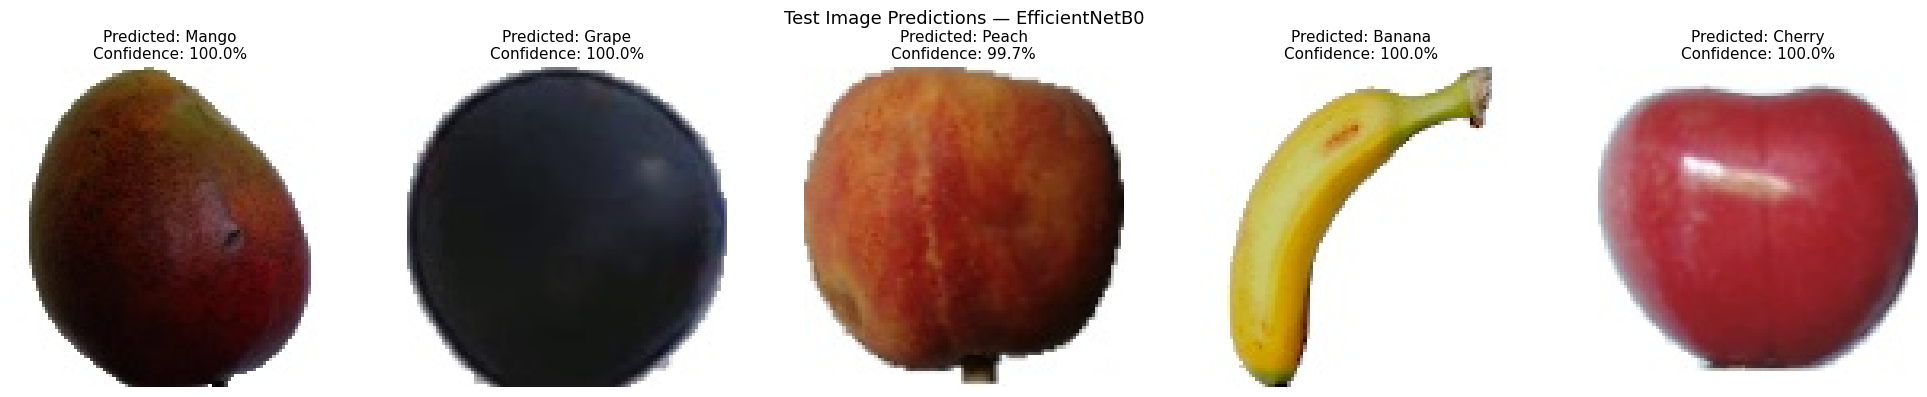

In [114]:
test_images = [f for f in os.listdir(TEST_DIR) if f.endswith('.jpg')]
print(f'Test images found: {len(test_images)}')

fig, axes = plt.subplots(1, len(test_images), figsize=(4 * len(test_images), 4))

# Handle case of single image
if len(test_images) == 1:
    axes = [axes]

for ax, img_name in zip(axes, test_images):
    img_path = os.path.join(TEST_DIR, img_name)

    img = keras_image.load_img(img_path, target_size=TL_SIZE)
    arr = preprocess_input(keras_image.img_to_array(img))
    arr = np.expand_dims(arr, axis=0)

    probs = eff_model.predict(arr, verbose=0)[0]
    pred  = CLASSES[np.argmax(probs)]
    conf  = probs.max()

    ax.imshow(keras_image.load_img(img_path))
    ax.set_title(f'Predicted: {pred}\nConfidence: {conf:.1%}', fontsize=11)
    ax.axis('off')

plt.suptitle('Test Image Predictions — EfficientNetB0', fontsize=13)
plt.tight_layout()
plt.show()